# Proyecto MD - Predictor del autismo en personas

1. [Introducción](#introduccion)

   1.1 [Preparador](#preparador)

   1.2 [Análisis de variables](#analisis_variables)

2. [Pipeline](#pipeline)

   2.1 [Componentes](#componentes)

   2.2 [Métricas de validación y evaluación](#metricas)

   2.3 [Construcción de prototipos](#prototipos)

3. [Experimentos](#experimentos)

   3.1 [Análisis de la pipeline base](#modelo_base)

   3.2 [Análisis del componente Detector de Outliers](#outliers)

   3.3 [Análisis del componente Estandarizador](#estandarizador)

   3.4 [Análisis de la pipeline avanzada](#pipeline_avanzada)

   3.5 [Análisis del componente Modelo](#modelo)

   3.6 [Análisis del umbral](#umbral)

   3.7 [Mejor pipeline](#mejor_pipeline)

4. [Interpretación](#interpretabilidad)

5. [Conclusiones](#conclusiones)

<a id="introduccion"></a>
# 1. Introducción

El problema elegido para este proyecto es la **predicción del autismo en personas** a partir del dataset `Autism-Adult-Data.csv`.

Para realizar lo anterior, haremos lo siguiente:
* Analizar nuestro problema
* Crear la mejor pipeline posible
* Reflexionar qué tan buena es la solución

### Configuración inicial

In [44]:
import warnings

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from functions_scripts.load import read_data
from classes import Preparador, Imputer, Transformador, OutlierDetector

from sklearn.tree import DecisionTreeClassifier
from sklearn.base import TransformerMixin, BaseEstimator
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split, cross_val_score, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, precision_recall_curve, make_scorer, average_precision_score

seed = 123
np.random.seed(123)
test_size = 0.2

# warnings.filterwarnings("ignore") (Para surprimir los warnings)

<a id="preparador"></a>
## 1.1 Preparador

Para comenzar, vamos a crear una clase denominada "Preparador", cuyo fin es ganar orden y limpieza
en nuestro dataset, pero sin cambiar ningún dato que pueda afectar a la solución final.

Realiza lo siguiente:
* Renombra columnas
* Elimina columnas innecesarias
* Pone a las columnas a1_score...a10_score: 0 => No, 1 => Si
* Limpia el texto de cada columna
* Convierte los valores perdidos: "?" => NaN
* Formatea columnas: category, float32

Se puede ejecutar para ver el antes y el después del dataset.

In [45]:
import numpy as np
import pandas as pd
from sklearn.base import TransformerMixin, BaseEstimator

class Preparador(TransformerMixin, BaseEstimator):
    def __init__(self):
        pass

    def preparar(self, X: pd.DataFrame):
        X = self.__rename(X)
        X = self.__column_del(X)
        X = self.__invert_meaning_answers(X)
        X = self.__clean_text(X)
        X = self.__replace_missing(X)
        X = self.__type_variables(X)
        return X
    
    def __rename(self, X: pd.DataFrame):
        """Pasa todas las columnas a minuscula y renombra las columnas con nombres erróneos"""
        Xaux = X.rename(columns=dict((col, col.lower()) for col in X.columns))
        Xaux = Xaux.rename(columns={'jundice': 'jaundice', 'austim': 'family_pdd', 'contry_of_res': 'country_of_res', 'class/asd': 'class'})
        return Xaux
    
    def __column_del(self, X: pd.DataFrame):
        """ Elimina las columnas """
        X = X.drop(columns=["id", "result", "age_desc"])
        return X

    def __invert_meaning_answers(self, X: pd.DataFrame):
        """ En info/Dataset_Autism.pdf se explica que las siguientes columnas tienen los valores "al revés" """
        cols = ["a2_score", "a3_score", "a4_score", "a5_score", "a6_score", "a9_score"]
        X[cols] = np.abs(X[cols] - 1)
        return X
    
    def __type_variables(self, X: pd.DataFrame):
        """ Pasa las variables a categoricas y numéricas a dichos tipos """
        cols_score = ["a1_score", "a2_score", "a3_score", "a4_score", "a5_score",
                "a6_score", "a7_score", "a8_score", "a9_score", "a10_score"]
        X[cols_score] = np.where(X[cols_score] == 1, "agree", "disagree")

        cols_cat = ["a1_score", "a2_score", "a3_score", "a4_score", "a5_score",
                "a6_score", "a7_score", "a8_score", "a9_score", "a10_score",
                "gender", "ethnicity", "jaundice", "family_pdd", "country_of_res",
                "used_app_before", "relation", "class"]
        X[cols_cat] = X[cols_cat].astype('category')

        cols_num = ["age"]
        X[cols_num] = X[cols_num].apply(pd.to_numeric, errors='coerce').astype(np.float32)
        return X

    def __clean_text(self, X: pd.DataFrame):
        """Minimiza, borra espacios y convierte '?' en NaN"""
        cols = ['gender', 'ethnicity', 'jaundice', 'family_pdd', 'country_of_res', 'used_app_before', 'relation', 'class']
        X[cols] = X[cols].apply(lambda x: x.str.lower().str.replace(" ", "", regex=False))
        return X
    
    def __replace_missing(self, X: pd.DataFrame):
        """Convierte los '?' en NaN para que el imputador los detecte"""
        X = X.replace('?', np.nan) # ===============================================================================
        return X
    
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return self.preparar(X)

if __name__ == '__main__':
    df = pd.read_csv("data/Autism-Adult-Data.csv", delimiter=',')
    preparador = Preparador()

    print("============================")
    print("    DATASET ORIGINAL ")
    print("============================\n")
    df.info()

    print("\n---------------------------- DOMINIO DE VARIABLES ----------------------------\n")
    print("A1_Score...A10_Score: ", np.unique(df["A1_Score"]))
    print("age: ", np.unique(df["age"]))
    print("gender: ", np.unique(df["gender"]))
    print("ethnicity: ", np.unique(df["ethnicity"]))
    print("jundice: ", np.unique(df["jundice"]))
    print("austim: ", np.unique(df["austim"]))
    print("contry_of_res: ", np.unique(df["contry_of_res"]))
    print("used_app_before: ", np.unique(df["used_app_before"]))
    print("relation: ", np.unique(df["relation"]))
    print("Class/ASD: ", np.unique(df["Class/ASD"]))

    df = preparador.preparar(df)

    print("\n")
    print("============================")
    print("    DATASET PREPARADO ")
    print("============================\n")
    df.info()

    print("\n---------------------------- DOMINIO DE VARIABLES ----------------------------\n")
    print("a1_score...a10_score: ", list(df["a1_score"].cat.categories))
    print("age: ", np.unique(df["age"]))
    print("gender: ", list(df["gender"].cat.categories))
    print("ethnicity: ", list(df["ethnicity"].cat.categories))
    print("jaundice: ", list(df["jaundice"].cat.categories))
    print("family_pdd: ", list(df["family_pdd"].cat.categories))
    print("country_of_res: ", list(df["country_of_res"].cat.categories))
    print("used_app_before: ", list(df["used_app_before"].cat.categories))
    print("relation: ", list(df["relation"].cat.categories))
    print("class: ", list(df["class"].cat.categories))

    print("\nNota: Los valores perdidos en las variables category no se ven, pero en realidad existen, se puede ver arriba en la columna \"Non-Null Count\"")

    DATASET ORIGINAL 

<class 'pandas.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   id               704 non-null    int64
 1   A1_Score         704 non-null    int64
 2   A2_Score         704 non-null    int64
 3   A3_Score         704 non-null    int64
 4   A4_Score         704 non-null    int64
 5   A5_Score         704 non-null    int64
 6   A6_Score         704 non-null    int64
 7   A7_Score         704 non-null    int64
 8   A8_Score         704 non-null    int64
 9   A9_Score         704 non-null    int64
 10  A10_Score        704 non-null    int64
 11  age              704 non-null    str  
 12  gender           704 non-null    str  
 13  ethnicity        704 non-null    str  
 14  jundice          704 non-null    str  
 15  austim           704 non-null    str  
 16  contry_of_res    704 non-null    str  
 17  used_app_before  704 non-null    str  
 18

<a id="analisis_variables"></a>
## 1.2 Análisis de variables

Una vez construido nuestro Preparador, vamos a analizar las variables de entrada y su relación con la variable de salida.

Como nota, cuando pongamos __"↑ Autismo"__ o __"↓ Autismo"__, nos referiremos a la mayor o menor probabilidad de tenerlo.

In [46]:
preparador = Preparador()

df = pd.read_csv("data/Autism-Adult-Data.csv", delimiter=',')
df = preparador.preparar(df)

X, y = df[df.columns[:-1]], df[df.columns[-1]]

In [47]:
def dibujar_relacion_variable_entrada_con_salida(X: pd.DataFrame, col: str, title: str, legend: bool, ax=None):
    if ax is None:
        fig, ax = plt.subplots(2, 5, figsize=(15, 6))
        axes = ax.ravel()
    
    ct = pd.crosstab(X[col], y)
    ct.columns = ["hasn't autism", "has autism"]
    ct.plot(kind="bar", ax=ax, legend=legend)
    ax.set_title(title)
    ax.set_xlabel("")
                
    return ax

### Relación de las 10 preguntas con la variable de salida

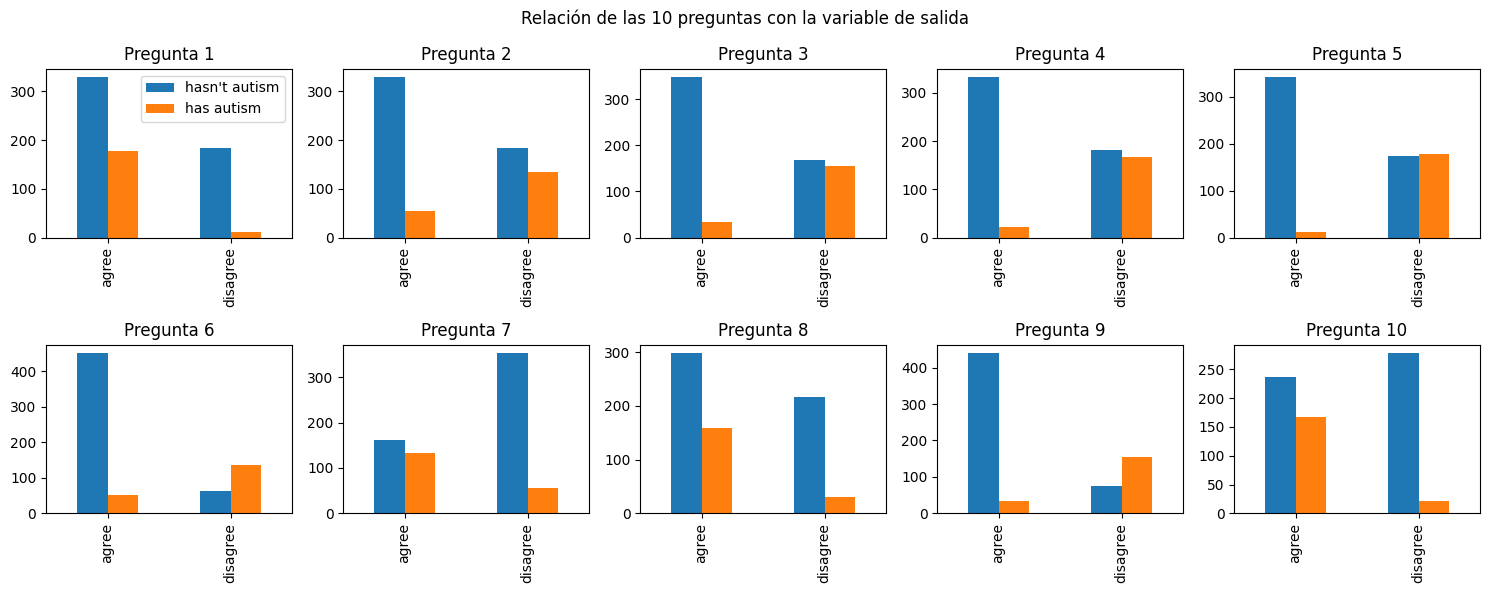

In [48]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i in range(10):
    col = X.columns[i]
    dibujar_relacion_variable_entrada_con_salida(X, col, f"Pregunta {i+1}", legend=(i == 0), ax=axes[i])
            
fig.suptitle("Relación de las 10 preguntas con la variable de salida")                   
fig.tight_layout()
plt.show()

<div style="display: flex; justify-content: center;">

| # | Pregunta | Dirección |
|---|---|---|
| 1 | I often notice small sounds when others do not. | Agree → ↑ Autismo |
| 2 | I usually concentrate more on the whole picture, rather than the small details. | Agree → ↓ Autismo |
| 3 | I find it easy to do more than one thing at once. | Agree → ↓ Autismo |
| 4 | If there is an interruption, I can switch back to what I was doing very quickly. | Agree → ↓ Autismo |
| 5 | I find it easy to read between the lines when someone is talking to me. | Agree → ↓ Autismo |
| 6 | I know how to tell if someone listening to me is getting bored. | Agree → ↓ Autismo |
| 7 | When I’m reading a story, I find it difficult to work out the characters’ intentions. | Agree → ↑ Autismo |
| 8 | I like to collect information about categories of things. | Agree → ↑ Autismo |
| 9 | I find it easy to work out what someone is thinking or feeling just by looking at their face. | Agree → ↓ Autismo |
| 10 | I find it difficult to work out people’s intentions. | Agree → ↑ Autismo |

</div>

### Relación de las variables binarias con la variable de salida

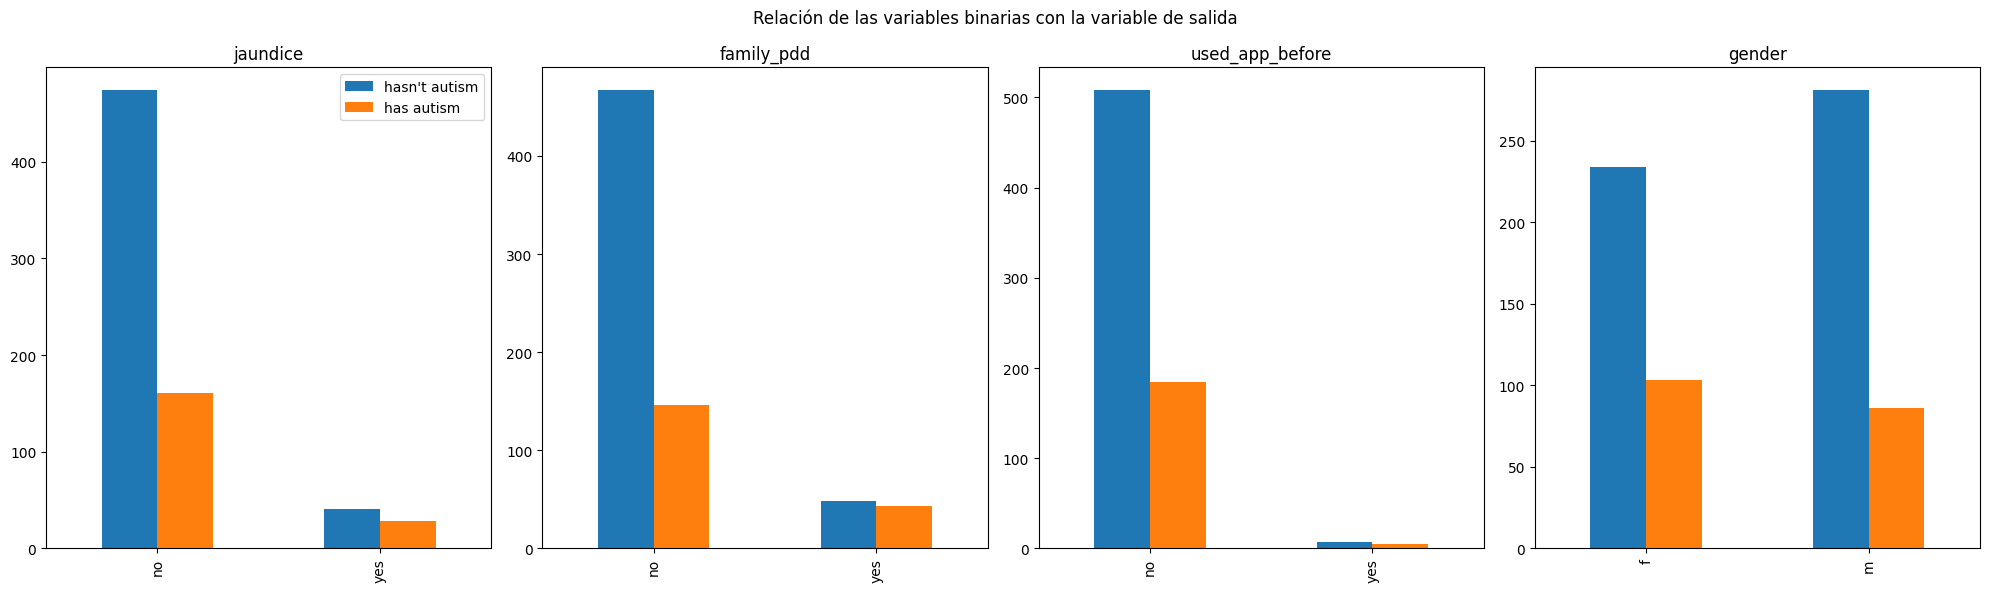

In [49]:
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
axes = axes.ravel()

cols = ["jaundice", "family_pdd", "used_app_before", "gender"]
for i, col in enumerate(cols):
    dibujar_relacion_variable_entrada_con_salida(X, col, col, legend=(i == 0), ax=axes[i])
            
fig.suptitle("Relación de las variables binarias con la variable de salida")
fig.tight_layout()
plt.show()

<div style="display: flex; justify-content: center;">

| Caracteristica | Dirección |
|---|---|
| Jaundice (Ictericia) | yes → ↑ Autismo |
| Family pdd | yes → ↑ Autismo |
| Used app before | yes → ↑ Autismo |
| Gender | m → ↓ Autismo |

</div>

### Relación de las variables restantes con la variable de salida

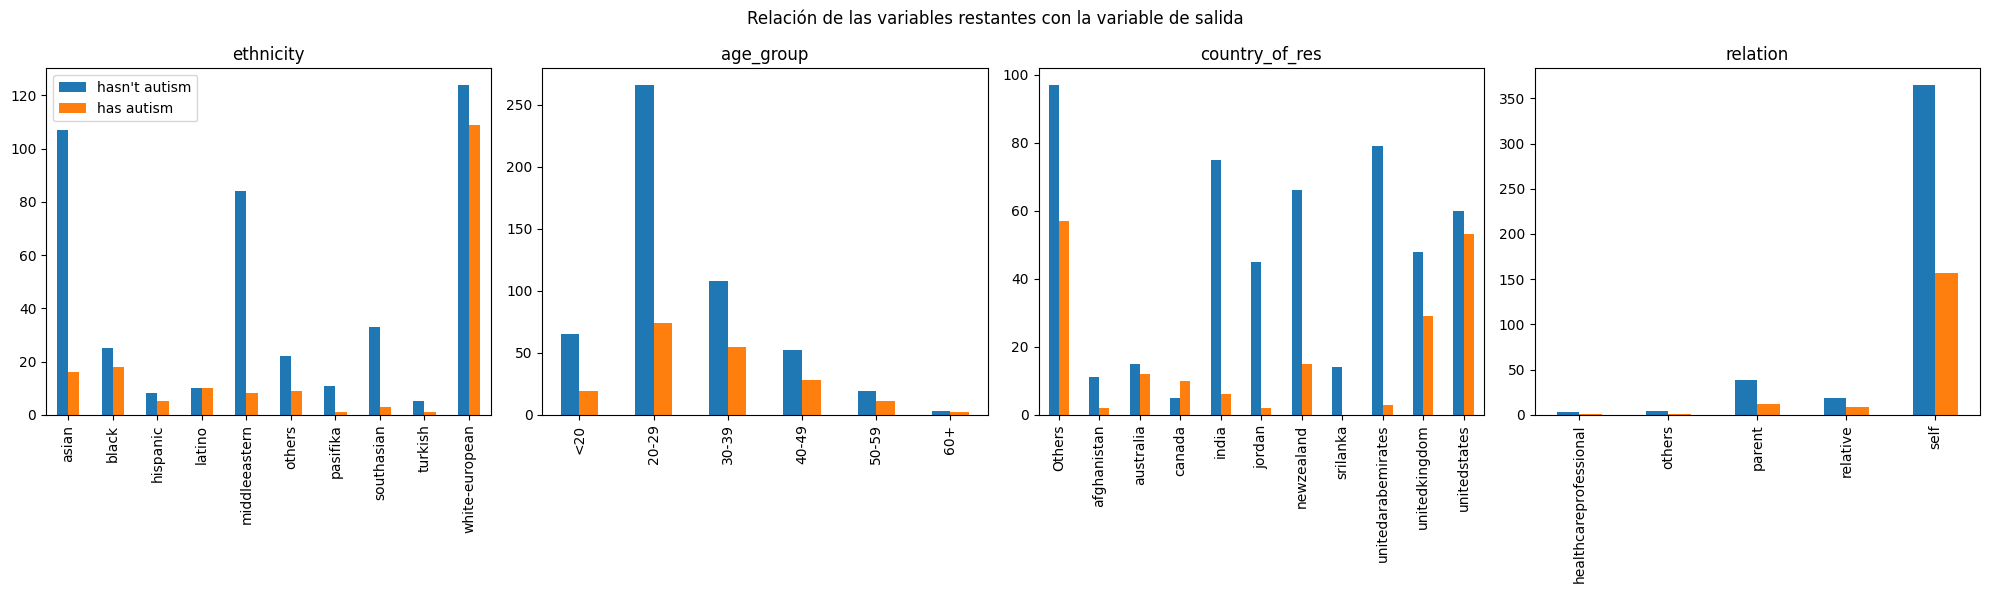

In [50]:
# Formateamos resultados
Xaux = X.copy()
bins = [0, 19, 29, 39, 49, 59, 1000] 
labels = ['<20', '20-29', '30-39', '40-49', '50-59', '60+']
Xaux["age_group"] = pd.cut(Xaux["age"], bins=bins, labels=labels)

top_countries = Xaux["country_of_res"].value_counts().nlargest(10).index
Xaux["country_of_res"] = Xaux["country_of_res"].apply(lambda x: x if x in top_countries else "Others")

# Mostramos los graficos
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
axes = axes.ravel()

cols = ["ethnicity", "age_group", "country_of_res", "relation"]
for i, col in enumerate(cols):
    dibujar_relacion_variable_entrada_con_salida(Xaux, col, col, legend=(i == 0), ax=axes[i])
            
fig.suptitle("Relación de las variables restantes con la variable de salida")
fig.tight_layout()
plt.show()

Nota: En la etnia, pais de residencia y relacion hay pocos datos de cada categoria, por lo que los resultados pueden ser engañosos.

* Ethnicity:
    * ↑ Autismo: black, hispanic, latino, white-european.
    * ↓ Autismo: middleeastem, pasifika, southasian, turkish.

* Age group:
    * ↑ Autismo: De 30 hacia arriba.
    * ↓ Autismo: De 30 hacia abajo.

* Country of residence (Mostramos los 10 paises con más datos):
    * ↑ Autismo: australia, canada, unitedkingdom, unitedstates
    * ↓ Autismo: afghanistan, india, jordan, newzealand, srilanka, unitedarabemirates

* Relation: No aporta demasiada información porque la mayoría de ejemplos pertenecen a la categoría "self",
por lo que no hay una gran variedad de información, por ello en la siguiente celda la eliminamos.

In [51]:
X = X.drop(columns=["relation"])

<a id="pipeline"></a>
# 2. Pipeline

A continuación, presentaremos toda la infraestructura creada para poder resolver el problema de la forma más eficiente posible.

Para ello, necesitaremos 2 conjuntos de datos: test y resto, en la celda de abajo los creamos.

In [52]:
X_resto, X_test, y_resto, y_test = train_test_split(X, y, test_size=test_size, random_state=seed, stratify=y)

y_resto = y_resto.map({'no': 0, 'yes': 1})
y_test = y_test.map({'no': 0, 'yes': 1})

<a id="componentes"></a>
## 2.1 Componentes

Los componentes principales son:

- **Imputer**: trata los valores perdidos en variables numéricas y categóricas.
- **Transformador**: convierte variables categóricas a una representación numérica.
- **OutlierDetector**: detecta y reemplaza valores atípicos.
- **Estandarizador**: escala las variables numéricas para mejorar el comportamiento de KNN.
- **Modelo (KNN o Árbol de decisión)**: modelo base utilizado para la clasificación.

### Imputador

In [53]:
from sklearn.base import TransformerMixin, BaseEstimator
from typing import Literal
import numpy as np
import pandas as pd

class Imputer(TransformerMixin, BaseEstimator):
	"""Imputador de valores perdidos para variables categóricas y numéricas por distintos métodos"""
	def __init__(
			self,
			metodo_imputacion_vars_num: Literal["media", "mediana"]="mediana",
			metodo_imputacion_vars_cat: Literal["moda", "missing"]="missing"
		) -> None:

		self._opciones_met_imp_vars_num = ["media", "mediana"]
		self._opciones_met_imp_vars_cat = ["moda", "missing"]
        
		if metodo_imputacion_vars_num not in self._opciones_met_imp_vars_num:
			raise ValueError(f"[ERROR]: La opción de imputación numérica '{metodo_imputacion_vars_num}' \
					no está disponible. Usar solo [{', '.join(self._opciones_met_imp_vars_num)}]")
		if metodo_imputacion_vars_cat not in self._opciones_met_imp_vars_cat:
			raise ValueError(f"[ERROR]: La opción de imputación categórica '{metodo_imputacion_vars_cat}' \
					no está disponible. Usar solo [{', '.join(self._opciones_met_imp_vars_cat)}]")
		
		self.metodo_imputacion_vars_num = metodo_imputacion_vars_num
		self.metodo_imputacion_vars_cat = metodo_imputacion_vars_cat

		self._valores_imputacion_vars_num = {}
		self._valores_imputacion_vars_cat = {}

	def fit(self, X: pd.DataFrame, y: pd.DataFrame | None = None):
		# Localizar las columnas en las que hay que imputar
		nombres_columnas_objetivo = []
		for nombre_columna in X.columns:
			if X[nombre_columna].dtype == "category":
				if np.where(X[nombre_columna].isna())[0].size > 0:
					nombres_columnas_objetivo.append(nombre_columna)
			else:
				if X[nombre_columna].isna().any():
					nombres_columnas_objetivo.append(nombre_columna)
		
		# Aprender los valores a imputar en las columnas objetivo
		for nombre_columna in nombres_columnas_objetivo:
			if X[nombre_columna].dtype == "category":
				if self.metodo_imputacion_vars_cat == "moda":
					# Al hacer lo así a moda podría ser el valor perdido, pero en nuestro dataset no
					self._valores_imputacion_vars_cat[nombre_columna] = X.loc[~X[nombre_columna].isna(), nombre_columna].mode()[0]
				elif self.metodo_imputacion_vars_cat == "missing":
					self._valores_imputacion_vars_cat[nombre_columna] = "missed"
			else:
				if self.metodo_imputacion_vars_num == "media":
					self._valores_imputacion_vars_num[nombre_columna] = np.nanmean(X[nombre_columna])
				elif self.metodo_imputacion_vars_num == "mediana":
					self._valores_imputacion_vars_num[nombre_columna] = np.nanmedian(X[nombre_columna])
		return self
	
	def transform(self, X: pd.DataFrame):
		Xaux = pd.DataFrame(X).copy()
		
		for nombre_columna in self._valores_imputacion_vars_cat.keys():
			Xaux[nombre_columna] = Xaux[nombre_columna].astype("object")
			Xaux.loc[Xaux[nombre_columna].isna(), nombre_columna] = self._valores_imputacion_vars_cat[nombre_columna]
			Xaux[nombre_columna] = Xaux[nombre_columna].astype("category")

		for nombre_columna in self._valores_imputacion_vars_num.keys():
			Xaux.loc[Xaux[nombre_columna].isna(), nombre_columna] = self._valores_imputacion_vars_num[nombre_columna]

		return Xaux

if __name__ == '__main__':
    df = pd.read_csv("data/Autism-Adult-Data.csv", delimiter=',')
    preparador = Preparador()
    df = preparador.preparar(df)

    print("============================")
    print("    SIN IMPUTACIÓN ")
    print("============================\n")
    df.info()

    imputer = Imputer(metodo_imputacion_vars_num="mediana", metodo_imputacion_vars_cat="moda")
    df = imputer.fit_transform(df)

    print("\n")
    print("============================")
    print("    CON IMPUTACIÓN ")
    print("============================\n")
    df.info()

    SIN IMPUTACIÓN 

<class 'pandas.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   a1_score         704 non-null    category
 1   a2_score         704 non-null    category
 2   a3_score         704 non-null    category
 3   a4_score         704 non-null    category
 4   a5_score         704 non-null    category
 5   a6_score         704 non-null    category
 6   a7_score         704 non-null    category
 7   a8_score         704 non-null    category
 8   a9_score         704 non-null    category
 9   a10_score        704 non-null    category
 10  age              702 non-null    float32 
 11  gender           704 non-null    category
 12  ethnicity        609 non-null    category
 13  jaundice         704 non-null    category
 14  family_pdd       704 non-null    category
 15  country_of_res   704 non-null    category
 16  used_app_before  704 non-null    c

### Transformador

In [54]:
import numpy as np
import pandas as pd

from typing import Literal
from sklearn.base import TransformerMixin, BaseEstimator

class Transformador(TransformerMixin, BaseEstimator):

    def __init__(self, metodo_cat_num: Literal["orden", "conteo", "ohe", "binary"]="orden") -> None:
        opciones = ["orden", "conteo", "ohe", "binary"]
        
        if metodo_cat_num not in opciones:
            raise ValueError(f"[ERROR]: La opción de imputación numérica '{metodo_cat_num}' \
                    no está disponible. Usar solo [{', '.join(opciones)}]")
        
        self.metodo_cat_num = metodo_cat_num
        self._correspondencias = {}

    def fit(self, X: pd.DataFrame, y=None):
        columnas_cat = X.select_dtypes(include='category').columns
        for col in columnas_cat:
            if self.metodo_cat_num == "orden":
                mapping = {}
                categorias = X[col].cat.categories
                for i, cat in enumerate(categorias):
                    mapping[cat] = i
                self._correspondencias[col] = mapping

            elif self.metodo_cat_num == "conteo":
                mapping = {}
                conteo = X[col].value_counts()
                for cat in conteo.index:
                    mapping[cat] = conteo[cat]
                self._correspondencias[col] = mapping

            elif self.metodo_cat_num == "ohe":
                categorias = list(X[col].cat.categories)
                self._correspondencias[col] = categorias

            elif self.metodo_cat_num == "binary":
                mapping = {}
                categorias = list(X[col].cat.categories)
                for i, cat in enumerate(categorias):
                    mapping[cat] = i

                # Bits necesarios
                n = len(categorias)
                bits = int(np.ceil(np.log2(n))) if n > 1 else 1
                self._correspondencias[col] = {
                    "mapping": mapping,
                    "bits": bits
                }

        return self

    def transform(self, X):
        Xaux = pd.DataFrame(X).copy()
        for col in Xaux.select_dtypes("category").columns:
            Xaux[col] = Xaux[col].astype(object)

        new_cols = {}
        cols_to_drop = []
        for col in list(self._correspondencias.keys()):
            if self.metodo_cat_num in ["orden", "conteo"]:
                mapping = self._correspondencias[col]
                Xaux[col] = Xaux[col].map(mapping).astype("float32")

            elif self.metodo_cat_num == "ohe":
                categorias = self._correspondencias[col]
                for cat in categorias:
                    new_cols[f"{col}_{cat}"] = (Xaux[col] == cat).astype("float32")
                cols_to_drop.append(col)

            elif self.metodo_cat_num == "binary":
                info = self._correspondencias[col]
                mapping = info["mapping"]
                bits = info["bits"]

                numeros = Xaux[col].map(mapping).fillna(0).astype("float32").to_numpy()
                for i in range(bits):
                    new_cols[f"{col}_bit_{i}"] = (numeros >> i) & 1
                cols_to_drop.append(col)

        if cols_to_drop:
            Xaux = Xaux.drop(columns=cols_to_drop)
        if new_cols:
            Xaux = pd.concat([Xaux, pd.DataFrame(new_cols, index=Xaux.index)], axis=1)

        return Xaux
    
if __name__ == '__main__':
    df = pd.read_csv("data/Autism-Adult-Data.csv", delimiter=',')
    preparador = Preparador()
    df = preparador.preparar(df)

    print("=============================")
    print("    SIN TRANSFORMACION")
    print("=============================\n")

    imputer = Imputer()
    df = imputer.fit_transform(df)
    df.info()

    
    print("\n=============================")
    print("    CON TRANSFORMACION")
    print("=============================")
    
    transformador = Transformador(metodo_cat_num="orden")
    df = transformador.fit_transform(df)
    df.info()

    SIN TRANSFORMACION

<class 'pandas.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   a1_score         704 non-null    category
 1   a2_score         704 non-null    category
 2   a3_score         704 non-null    category
 3   a4_score         704 non-null    category
 4   a5_score         704 non-null    category
 5   a6_score         704 non-null    category
 6   a7_score         704 non-null    category
 7   a8_score         704 non-null    category
 8   a9_score         704 non-null    category
 9   a10_score        704 non-null    category
 10  age              704 non-null    float32 
 11  gender           704 non-null    category
 12  ethnicity        704 non-null    category
 13  jaundice         704 non-null    category
 14  family_pdd       704 non-null    category
 15  country_of_res   704 non-null    category
 16  used_app_before  704 non-null  

### Outlier Detector

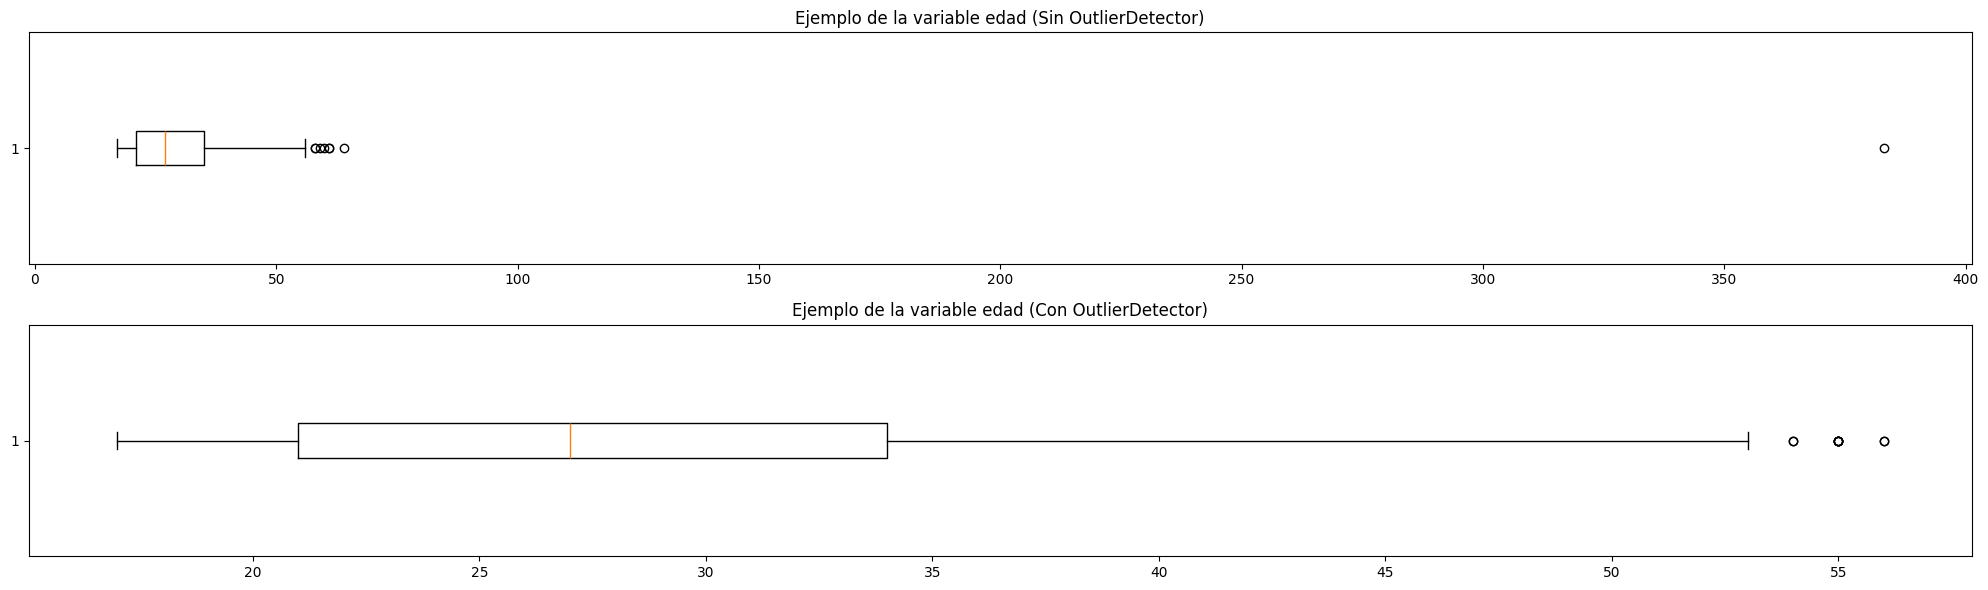

In [55]:
from sklearn.base import TransformerMixin, BaseEstimator
import numpy as np
import pandas as pd

class OutlierDetector(TransformerMixin, BaseEstimator):
	"""Detector y corrector de outliers por distintos métodos"""
	def __init__(self, k: float | None = 1.5, deteccion: str | None = "iqr", reemplazo: str | None = "mediana"):
		opciones_deteccion = ["iqr", "mediastd"]
		opciones_reemplazo = ["mediana", "media", "min", "max", "moda"]
        
		if deteccion not in opciones_deteccion:
			raise ValueError(f"[ERROR]: La opción de deteccion '{deteccion}' no está disponible. Usar solo [{', '.join(opciones_deteccion)}]")
		if reemplazo not in opciones_reemplazo:
			raise ValueError(f"[ERROR]: La opción de reemplazo '{reemplazo}' no está disponible. Usar solo [{', '.join(opciones_reemplazo)}]")
		
		self.stats = None
		self.modas = None
		self.columns = None
		self.mins = {}
		self.maxs = {}
		self.k = k
		self.deteccion = deteccion
		self.reemplazo = reemplazo

	def fit(self, X: pd.DataFrame, y: pd.DataFrame | None = None):
		if isinstance(X, np.ndarray):
			X = pd.DataFrame(X)
		if isinstance(y, np.ndarray):
			y = pd.DataFrame(y)

		self.stats = X.describe()
		# Evita columnas categoricas y columnas binarias
		self.columns = [column 
				  for column in X.columns 
				    if (X[column].dtype != object and 
			            len(np.unique(X[column].dropna())) > 2)]
				
		if self.reemplazo == "moda":
			self.modas = X.mode()
		elif self.reemplazo in ["min", "max"]: # Me guardo los minimos y maximos que NO sean outliers
			for column in self.columns:
				if self.deteccion == "iqr":
					Q1 = self.stats[column]["25%"]
					Q3 = self.stats[column]["75%"]
					IQR = Q3-Q1

					lim_sup = Q3 + self.k*IQR
					lim_inf = Q1 - self.k*IQR
				else: # mediastd
					media = self.stats[column]["mean"]
					std = self.stats[column]["std"]

					lim_sup = media + self.k * std
					lim_inf = media - self.k * std

				mask_sup = X[column] > lim_sup
				mask_inf = X[column] < lim_inf

				self.mins[column] = X.loc[~(mask_sup | mask_inf), column].min()
				self.maxs[column] = X.loc[~(mask_sup | mask_inf), column].max()

		return self
	
	def transform(self, X: pd.DataFrame):
		if isinstance(X, np.ndarray):
			Xaux = pd.DataFrame(X).copy()
		else:
			Xaux = X.copy()

		for column in self.columns:
			if self.deteccion == "iqr":
				Q1 = self.stats[column]["25%"]
				Q3 = self.stats[column]["75%"]
				IQR = Q3-Q1

				lim_sup = Q3 + self.k*IQR
				lim_inf = Q1 - self.k*IQR
			else:
				media = self.stats[column]["mean"]
				std = self.stats[column]["std"]

				lim_sup = media + self.k * std
				lim_inf = media - self.k * std

			mask_sup = Xaux[column] > lim_sup
			mask_inf = Xaux[column] < lim_inf

			if self.reemplazo == "mediana":
				value = self.stats[column]["50%"]
			elif self.reemplazo == "media":
				value = self.stats[column]["mean"]
			elif self.reemplazo == "moda":
				value = self.modas[column][0]
			elif self.reemplazo == "min":
				value = self.mins[column]
			elif self.reemplazo == "max":
				value = self.maxs[column]

			# TODO: Decidir que hacer con las columnas int
			if Xaux.loc[:, column].dtype == int:
				value = round(value)

			Xaux.loc[mask_sup, column] = value
			Xaux.loc[mask_inf, column] = value
		return Xaux
	
if __name__ == '__main__':
	df = pd.read_csv("data/Autism-Adult-Data.csv", delimiter=',')
	preparador = Preparador()
	df = preparador.preparar(df)

	imputer = Imputer()
	df = imputer.fit_transform(df)
	
	transformador = Transformador(metodo_cat_num="orden")
	df_sin_outlier_detector = transformador.fit_transform(df)

	outlier_detector = OutlierDetector(k=1.5, deteccion="iqr", reemplazo="mediana")
	df_con_outlier_detector = outlier_detector.fit_transform(df_sin_outlier_detector)

	fig, axes = plt.subplots(2, 1, figsize=(20, 6))
	axes[0].set_title("Ejemplo de la variable edad (Sin OutlierDetector)")
	axes[0].boxplot(df_sin_outlier_detector["age"], vert=False)
	axes[1].set_title("Ejemplo de la variable edad (Con OutlierDetector)")
	axes[1].boxplot(df_con_outlier_detector["age"], vert=False)
	plt.tight_layout()
	plt.show()

### Estandarizador

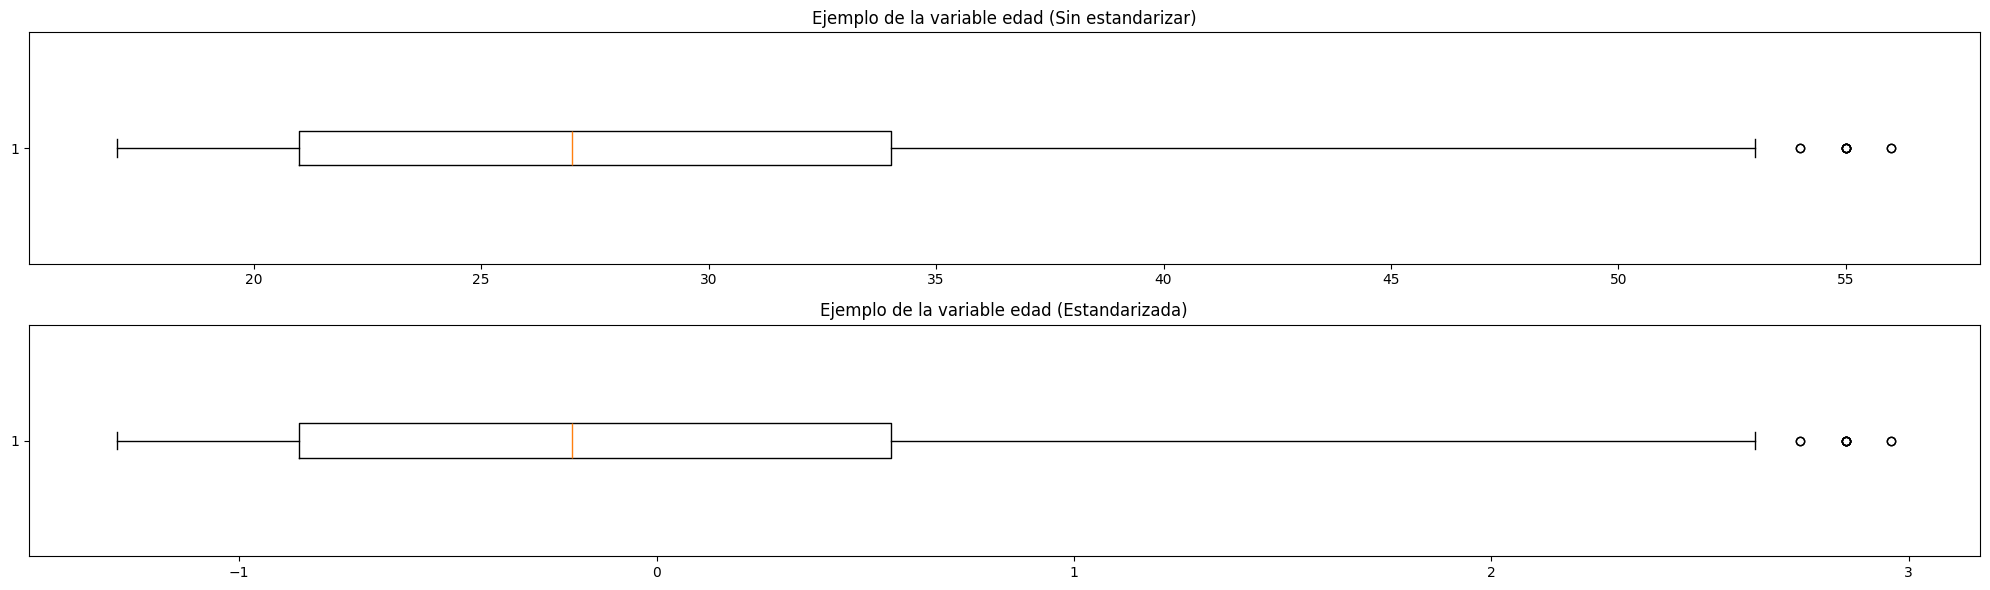

In [56]:
class Estandarizador(TransformerMixin, BaseEstimator):
    def __init__(self, metodo: Literal["minmax", "standard", "robust"]="standard") -> None:
        opciones = ["minmax", "standard", "robust"]
        
        if metodo not in opciones:
            raise ValueError(f"[ERROR]: La opción de estandarización '{metodo}' no está disponible. Usar solo [{', '.join(opciones)}]")
        
        self.metodo = metodo
        self._scaler = None

    def fit(self, X: pd.DataFrame, y=None):
        if self.metodo == "minmax":
            self._scaler = MinMaxScaler()
        elif self.metodo == "standard":
            self._scaler = StandardScaler()
        elif self.metodo == "robust":
            self._scaler = RobustScaler()

        self._scaler.fit(X)
        return self

    def transform(self, X: pd.DataFrame):
        return pd.DataFrame(self._scaler.transform(X), columns=X.columns, index=X.index)
    
if __name__ == '__main__':
    df = pd.read_csv("data/Autism-Adult-Data.csv", delimiter=',')
    preparador = Preparador()
    df = preparador.preparar(df)

    imputer = Imputer()
    df = imputer.fit_transform(df)
    
    transformador = Transformador(metodo_cat_num="orden")
    df = transformador.fit_transform(df)

    outlier_detector = OutlierDetector(k=1.5, deteccion="iqr", reemplazo="mediana")
    df_sin_estandarizar = outlier_detector.fit_transform(df)

    estandarizador = Estandarizador(metodo="standard")
    df_estandarizado = estandarizador.fit_transform(df_sin_estandarizar)

    fig, axes = plt.subplots(2, 1, figsize=(20, 6))
    axes[0].set_title("Ejemplo de la variable edad (Sin estandarizar)")
    axes[0].boxplot(df_sin_estandarizar["age"], vert=False)
    axes[1].set_title("Ejemplo de la variable edad (Estandarizada)")
    axes[1].boxplot(df_estandarizado["age"], vert=False)
    plt.tight_layout()
    plt.show()

### Modelo

Para el modelo no crearemos nuestra propia clase porque usaremos el KNN y el Arbol de decisión, y como ya están programados en sklearn y cada uno tiene diferentes hiperparametros no nos complicaremos.

Debajo dejamos los hiperparametros de cada uno.

KNeighborsClassifier:
* n_neighbors
* weights: "uniform", "distance"
* metric: "manhattan", "euclidean"

DecisionTreeClassifier:
* criterion (Medida impureza nodo): "gini", "entropy"
* min_samples_split (Numero minimo ejemplos rama):
    * Valor entero: Se refiere exactamente al número de ejemplos
    * Valor real: Se refiere a la proporción de ejemplos
* min_samples_leaf (Numero minimo ejemplos hoja):
    * Valor entero: Se refiere exactamente al número de ejemplos
    * Valor real: Se refiere a la proporción de ejemplos
* max_depth
* ccp_alpha (Umbral alfa eficaz): Valor real.
* random_state

<a id="metricas"></a>
## 2.2 Métricas de validación y evaluación

### Método de validación


Usamos un enfoque de **Pipeline + GridSearchCV** porque este dataset tiene alrededor de **700 instancias**, un tamaño intermedio en el que podemos permitirnos validación cruzada sin que el coste computacional sea excesivo.

**Por qué Pipeline:**
- Encadena en un solo objeto todos los pasos de preprocesado y modelado (detección de outliers, escalado y clasificador).
- Garantiza que cada transformación se ajusta solo con los datos de entrenamiento de cada fold, evitando fuga de información.
- Hace el flujo reproducible y más fácil de mantener.

**Por qué GridSearchCV:**
- Permite buscar sistemáticamente la mejor combinación de hiperparámetros del KNN (`n_neighbors`, `weights`, `p`).
- En un conjunto de ~700 filas, una búsqueda en malla con validación cruzada de 10 folds es viable.
- Devuelve el mejor modelo ya reentrenado y métricas por combinación para comparar decisiones.
- Como no tiene tantos hiperparametros es viable usar GridSearchCV en vez de RandomSearch.

**Tenemos varios métodos de validación posibles:**
- Hold Out (estratificación y repetición)
- K-Fold (estratificación)
- Leave-One-Out

**Por qué StratifiedKFold:**
- En este problema de clasificación, la variable objetivo puede estar desbalanceada.
- `StratifiedKFold` mantiene la proporción de clases en cada fold, reduciendo varianza en la estimación y haciendo la evaluación más estable que un KFold simple.


### Método de evaluación

Tenemos varios métodos de evaluación posibles:
- Dependientes del umbral:
    - Accuracy
    - F1-score

- Independientes del umbral:
    - AUC de la curva ROC
    - AUC de la curva Precisión-Recall

Para las medidas dependientes del umbral el accuracy es una medida bastante mala para datasets con desbalanceo
de clases porque no representa bien lo bueno que es el modelo en cada una de ellas, sino que lo hace de
manera general, por lo que si hay una clase que predomina bastante más frente a otra, el modelo puede ser muy bueno
en la clase mayoritaria y muy malo en clase minoritaria, y sin embargo, el accuracy saldría bastante alto. Por todo
lo anterior, usaremos el F1-score, ya que tiene en cuenta el recall y la precisión por clase, así que es inmune al
desbalanceo de clases, al mismo tiempo, cuando la precisión o el recall disminuyen penaliza bastante más que una simple
media por que hace la media geométrica entre la precisión y recall, pensando en nuestro problema en concreto, no tratamos con
falsos negativos delicados, como en el caso de un cancer, por lo que la prioridad es corregir lo mejor posible la clase
positiva y distinguir lo mejor posible la clase negativa.

Para las medidas independientes del umbral elegimos la **AUC de la curva Precisión-Recall**
en vez de la AUC de la curva ROC. La razón es de coherencia con la métrica dependiente del umbral: el F1-score se
calcula sobre la precisión y el recall de la clase positiva (autismo), y la curva Precisión-Recall mide exactamente
ese mismo trade-off a lo largo de todos los umbrales posibles. La curva ROC, en cambio, mezcla el comportamiento
sobre las dos clases (TPR vs FPR) y tiende a ser optimista cuando hay desbalance porque la clase mayoritaria
"infla" el FPR. Aunque nuestro desbalance es moderado (≈27/73), nos interesa más detectar bien los casos positivos
que distinguir bien los negativos, así que tanto F1-score como AUC-PR apuntan al mismo objetivo y son comparables
entre sí.

<a id="prototipos"></a>
## 2.3 Construcción de prototipos

In [57]:
nombre_componente_imputador = "imputador"
nombre_componente_transformador = "transformador"
nombre_componente_outlier = "outlier"
nombre_componente_estandarizador = "estandarizador"
nombre_componente_knn = "knn"
nombre_componente_arbol = "arbol"

In [73]:
param_grid_imputador = {
    f"{nombre_componente_imputador}__metodo_imputacion_vars_num": ["media", "mediana"],
    f"{nombre_componente_imputador}__metodo_imputacion_vars_cat": ["moda", "missing"]
}

param_grid_transformador = {
    f"{nombre_componente_transformador}__metodo_cat_num": ["orden", "conteo", "ohe", "binary"]
}

param_grid_outlier = {
    f"{nombre_componente_outlier}__k": [1.5, 3, 4.5],
    f"{nombre_componente_outlier}__deteccion": ["iqr", "mediastd"],
    f"{nombre_componente_outlier}__reemplazo": ["mediana", "media", "min", "max", "moda"]
}

param_grid_estandarizador = {
    f"{nombre_componente_estandarizador}__metodo": ["minmax", "standard", "robust"]
}

param_grid_knn = {
    f"{nombre_componente_knn}__n_neighbors": [3, 5, 7, 9, 11, 13],
    f"{nombre_componente_knn}__weights": ["uniform", "distance"],
    f"{nombre_componente_knn}__metric": ["manhattan", "euclidean"]
}

param_grid_arbol = {
    f"{nombre_componente_arbol}__criterion": ["gini", "entropy"], # entropy
    f"{nombre_componente_arbol}__min_samples_split": [10, 20, 50],
    f"{nombre_componente_arbol}__min_samples_leaf": [10, 20, 50],
    f"{nombre_componente_arbol}__max_depth": [5, 10],
    f"{nombre_componente_arbol}__ccp_alpha": [0, 0.001, 0.01]
}

In [59]:
def construir_prototipo_pipeline(
        imputador: Imputer=Imputer(),
        transformador: Transformador=Transformador(),
        outlier: OutlierDetector=None,
        estandarizador: Estandarizador=None,
        modelo: KNeighborsClassifier | DecisionTreeClassifier=KNeighborsClassifier()
    ) -> Pipeline:
    """ Se parte del pipeline base para agregarle los extras (Base = Imputador + Transformador) """

    pasos = [
        (nombre_componente_imputador, imputador),
        (nombre_componente_transformador, transformador)
    ]
    
    if outlier != None: pasos.append((nombre_componente_outlier, outlier))
    if estandarizador != None: pasos.append((nombre_componente_estandarizador, estandarizador))
    
    if isinstance(modelo, KNeighborsClassifier):
        pasos.append((nombre_componente_knn, modelo))
    elif isinstance(modelo, DecisionTreeClassifier):
        pasos.append((nombre_componente_arbol, modelo))

    return Pipeline(pasos)


<a id="experimentos"></a>
# 3. Experimentos

En esta sección se irá construyendo el pipeline final componente por componente estudiando las mejores configuraciones para cada uno de ellos.

El flujo que realizaremos será el siguiente:
* Pipeline base: Buscar la mejor configuración del Imputador + Transformador.
* Pipeline base + Outlier Detector: Añadir a la pipeline base el detector de outliers para analizar el impacto.
* Pipeline base + Estandarizador: Añadir a la pipeline base el estandarizador para analizar el impacto.
* Pipeline avanzada + (Knn / Arbol de decision): Tunear el modelo de la pipeline avanzada.

A continuación, dejamos el scorer y el cv que utilizaremos.

In [60]:
cv = StratifiedShuffleSplit(n_splits=10, random_state=seed)
scorer_dependiente_umbral = make_scorer(f1_score, response_method="predict", greater_is_better=True)
scorer_independiente_umbral = make_scorer(average_precision_score, response_method="predict_proba", greater_is_better=True)

In [61]:
def imprimir_resultados_grid(grid: GridSearchCV, nombres_componentes: list[str]):
    print("=======================")
    print("    Resultados")
    print("=======================\n")

    print("Componentes:")
    pipeline = grid.best_estimator_
    for nombre_componente in nombres_componentes:
        print(f"    {nombre_componente}:")

        componente = pipeline.named_steps[nombre_componente]
        for nombre_parametro, valor_parametro in componente.get_params().items():
            print(f"        {nombre_parametro}: {valor_parametro}")

    print("")
    print("Medidas:")
    print(f"    Score: {round(grid.best_score_, 4)}")

<a id="modelo_base"></a>
## 3.1 Análisis de la pipeline base

En este apartado buscaremos la mejor configuración del Imputador + Transformador.

In [62]:
# Creamos la mejor pipeline base
pipeline_base = construir_prototipo_pipeline()

param_grid = param_grid_imputador | param_grid_transformador
grid = GridSearchCV(
    estimator=pipeline_base,
    param_grid=param_grid,
    scoring=scorer_independiente_umbral,
    cv=cv
)

grid.fit(X_resto, y_resto)

# Recogemos el mejor imputador y transformador
mejor_imputador = grid.best_estimator_.named_steps[nombre_componente_imputador]
mejor_transformador = grid.best_estimator_.named_steps[nombre_componente_transformador]

# Mostramos los resultados
nombres_componentes_mostrar = [
    nombre_componente_imputador,
    nombre_componente_transformador
]
imprimir_resultados_grid(grid, nombres_componentes_mostrar)

    Resultados

Componentes:
    imputador:
        metodo_imputacion_vars_cat: moda
        metodo_imputacion_vars_num: media
    transformador:
        metodo_cat_num: ohe

Medidas:
    Score: 0.867


/home/eloy348/Escritorio/Universidad/Trabajos/.venv/lib64/python3.14/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
40 fits failed out of a total of 160.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
40 fits failed with the following error:
Traceback (most recent call last):
  File "/home/eloy348/Escritorio/Universidad/Trabajos/.venv/lib64/python3.14/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/eloy348/Escritorio/Universidad/Trabajos/.venv/lib64/python3.14/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs

Como podemos ver obtenemos un AUC de la curva precision-recall del 0.867.

<a id="outliers"></a>
## 3.2 Análisis del componente OutlierDetector

En este siguiente apartado analizaremos el impacto del OutlierDetector en la pipeline base anterior.

In [ ]:
# Creamos la pipeline
pipeline = construir_prototipo_pipeline(
    imputador=mejor_imputador,
    transformador=mejor_transformador,
    outlier=OutlierDetector()
)

param_grid = param_grid_outlier
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=scorer_independiente_umbral,
    cv=cv
)

grid.fit(X_resto, y_resto)

# Mostramos los resultados
imprimir_resultados_grid(grid, nombre_componente_outlier)

    Resultados

Componentes:
    outlier:
        deteccion: mediastd
        k: 1.5
        reemplazo: moda

Medidas:
    Score: 0.9004


Como se puede ver observamos una pequeña mejora introduciendo este componente, ya que pasamos de 0.8670 a 0.9004.

<a id="estandarizador"></a>
## 3.3 Análisis del componente Estandarizador

En este siguiente apartado analizaremos el impacto del Estandarizador en la pipeline base.

In [ ]:
# Creamos la pipeline
pipeline = construir_prototipo_pipeline(
    imputador=mejor_imputador,
    transformador=mejor_transformador,
    estandarizador=Estandarizador()
)

param_grid = param_grid_estandarizador
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=scorer_independiente_umbral,
    cv=cv
)

grid.fit(X_resto, y_resto)

# Mostramos los resultados
imprimir_resultados_grid(grid, nombre_componente_estandarizador)

    Resultados

Componentes:
    estandarizador:
        metodo: robust

Medidas:
    Score: 0.9594


Como se puede ver, observamos una mejora mucho mayor con este componente que con el OutlierDetector, ya que pasamos de 0.8670 a 0.9594.

<a id="pipeline_avanzada"></a>
## 3.4 Análisis de la pipeline avanzada

Como hemos podido ver en los anteriores experimentos es bueno introducir el OutlierDetector y el Estandarizador.

Por lo tanto, ahora introduciremos los 2 componentes y encontraremos la mejor configuración entre ellos y la pipeline base
para crear una pipeline más avanzada.

In [ ]:
# Creamos la pipeline
pipeline = construir_prototipo_pipeline(
    imputador=mejor_imputador,
    transformador=mejor_transformador,
    outlier=OutlierDetector(),
    estandarizador=Estandarizador()
)

param_grid = param_grid_outlier | param_grid_estandarizador
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=scorer_independiente_umbral,
    cv=cv
)

grid.fit(X_resto, y_resto)

# Recogemos el mejor outlier y estandarizador

mejor_outlier = grid.best_estimator_.named_steps[nombre_componente_outlier]
mejor_estandarizador = grid.best_estimator_.named_steps[nombre_componente_estandarizador]

# Mostramos los resultados
nombres_componentes_mostrar = [
    nombre_componente_imputador,
    nombre_componente_transformador,
    nombre_componente_outlier,
    nombre_componente_estandarizador
]
imprimir_resultados_grid(grid, nombres_componentes_mostrar)

    Resultados

Componentes:
    imputador:
        metodo_imputacion_vars_cat: moda
        metodo_imputacion_vars_num: media
    transformador:
        metodo_cat_num: ohe
    outlier:
        deteccion: mediastd
        k: 3
        reemplazo: media
    estandarizador:
        metodo: robust

Medidas:
    Score: 0.9621


Como consecuencia, al introducir los 2 componentes y encontrar la mejor configuración entre estos, vemos una mejora superior a las anteriores.

La maxima mejora que habíamos obtenido era al añadir el Estandarizador, dándonos un 0.9594, sin embargo, ahora con el detector de outliers y el estandarizador
obtenemos un 0.9621.

Ya tenemos nuestra pipeline avanzada, en las siguientes secciones veremos si podemos sacarle mayor rendimiento.

<a id="modelo"></a>
## 3.5 Análisis del componente Modelo

En este apartado, encontraremos el mejor modelo y la mejor configuración de este para la pipeline avanzada.

### Modelo KNN

In [76]:
# Creamos la pipeline
pipeline = construir_prototipo_pipeline(
    imputador=mejor_imputador,
    transformador=mejor_transformador,
    outlier=mejor_outlier,
    estandarizador=mejor_estandarizador,
    modelo=KNeighborsClassifier()
)

param_grid = param_grid_knn
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=scorer_independiente_umbral,
    cv=cv
)

grid.fit(X_resto, y_resto)

# Recogemos el componente
mejor_modelo = grid.best_estimator_.named_steps[nombre_componente_knn]

# Mostramos los resultados
imprimir_resultados_grid(grid, [nombre_componente_knn])

    Resultados

Componentes:
    knn:
        algorithm: auto
        leaf_size: 30
        metric: manhattan
        metric_params: None
        n_jobs: None
        n_neighbors: 13
        p: 2
        weights: distance

Medidas:
    Score: 0.9777


Con el modelo de tipo KNN tuneado subimos de un 0.9621 a un 0.9777.

### Modelo Arbol de decisión

In [74]:
# Creamos la pipeline
pipeline = construir_prototipo_pipeline(
    imputador=mejor_imputador,
    transformador=mejor_transformador,
    outlier=mejor_outlier,
    estandarizador=mejor_estandarizador,
    modelo=DecisionTreeClassifier()
)

param_grid = param_grid_arbol
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=scorer_independiente_umbral,
    cv=cv
)

grid.fit(X_resto, y_resto)

# Mostramos los resultados
imprimir_resultados_grid(grid, [nombre_componente_arbol])

    Resultados

Componentes:
    arbol:
        ccp_alpha: 0
        class_weight: None
        criterion: entropy
        max_depth: 10
        max_features: None
        max_leaf_nodes: None
        min_impurity_decrease: 0.0
        min_samples_leaf: 10
        min_samples_split: 10
        min_weight_fraction_leaf: 0.0
        monotonic_cst: None
        random_state: None
        splitter: best

Medidas:
    Score: 0.8292


Con el árbol de decisión el rendimiento baja muchísimo, aunque lo más probable es que como estamos usando GridSearch, no estamos buscando donde toca,
por lo que sería mucho mejor utilizar RandomSearch.

<a id="umbral"></a>
## 3.6 Análisis del umbral

<a id="mejor_pipeline"></a>
## 3.7 Mejor pipeline

### Justificación de la combinación elegida

El ranking anterior recoge **todas** las combinaciones posibles de los 4 tratamientos, asi que la
mejor fila no es un optimo greedy: es el optimo real sobre la rejilla de tratamientos.

Como hemos probado las 16 combinaciones, podemos leer dos cosas en la tabla:

- **¿Aporta este tratamiento?** Compara `baseline` con `baseline + X`. Si la AUC-PR sube, X aporta
  por si solo.
- **¿Necesita compañia?** Si `baseline + X` no mejora, pero `baseline + X + Y` si lo hace mas que
  `baseline + Y` solo, entonces X solo rinde acompañado.

### El caso del imputador en nuestros datos

En la tabla anterior se ve que **añadir el imputador con sus defaults empeora ligeramente la
AUC-PR** respecto a tenerlo apagado:

```
baseline + transformador + outlier + estandarizador               -> 0.9446  (sin imputador)
baseline + imputador + transformador + outlier + estandarizador   -> 0.9317  (con imputador)
```

A primera vista parece que el imputador es un lastre. Pero la lectura correcta es otra:

- El `Imputer()` por defecto rellena `age` con la **mediana** y las categoricas con la string
  `"missed"`.
- El `Transformador()` por defecto usa `"orden"`, que asigna 0, 1, 2... por orden alfabetico de las
  categorias. Añadir la categoria `"missed"` desplaza la numeracion y mete ruido.
- En cambio, cuando el `Basico` esta solo (sin imputador), tambien rellena con la mediana y
  codifica los NaN categoricos como `-1`. Hacen casi lo mismo, asi que el imputador no aporta nada
  y la diferencia (0.013) cae dentro del ruido de la CV.

Cuando, en el siguiente paso, el `GridSearchCV` puede **tunear los metodos**, el imputador cambia
a `media` y el transformador a `conteo` (que codifica por frecuencia, no por orden alfabetico).
Ahi el imputador entra en la combinacion ganadora con **AUC-PR = 0.9690**.

**Conclusion**: el imputador no es malo, lo que es malo es la pareja `Imputer(mediana, missing) +
Transformador("orden")`. Por eso decir "este tratamiento no aporta" mirando solo la tabla de
combinaciones con defaults es engañoso: hay que dejar tambien al `GridSearchCV` ajustar los
metodos dentro de cada bloque. Es el ejemplo claro de que un tratamiento puede no rendir solo y
si rendir acompañado.

### Que hace el GridSearchCV combinado

Una vez fijada *que combinacion de bloques* usar, el siguiente `GridSearchCV` afina **los
metodos** dentro de cada bloque (`media` vs `mediana`, `iqr` vs `mediastd`, `StandardScaler` vs
`RobustScaler`, `orden` vs `conteo` vs `ohe` vs `binary`, etc.) sobre toda la rejilla. Es la
busqueda fina, no la decision estructural — y es la que sube de 0.9446 a 0.9690.

In [65]:
# Busqueda combinada sobre todos los tratamientos a la vez

pipe = Pipeline([
    ('imputador', Imputer()),
    ('transformador', Transformador()),
    ('outlier', OutlierDetector()),
    ('estandarizador', StandardScaler()),
    ('clasificador', KNeighborsClassifier()),
])

param_grid = {
    "imputador__metodo_imputacion_vars_num": ["media", "mediana"],
    "imputador__metodo_imputacion_vars_cat": ["moda", "missing"],
    "transformador__metodo_cat_num": ["orden", "conteo", "ohe", "binary"],
    "estandarizador": [StandardScaler(), RobustScaler(), MinMaxScaler(), 'passthrough'], # passthrough evalúa dejar estandarizador en None
    "outlier__deteccion": ["iqr", "mediastd"],
    "outlier__reemplazo": ["mediana", "media", "min", "max", "moda"],
    # "modelo__n_neighbors": [1, 2, 3, 5, 8],                       # Dejar comentado hasta el final (antes de la entrega)
    # "modelo__weights": ["uniform", "distance"],                   # Dejar comentado hasta el final (antes de la entrega)
    # "modelo__p": [1, 2],                                          # Dejar comentado hasta el final (antes de la entrega)
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=seed), # n_splits = 10, dataset pequeño
    n_jobs=-1, # para usar todos los nucleos del cpu
    scoring="average_precision",   # AUC-PR, coherente con el F1 que usaremos para fijar el umbral
    return_train_score=True)

grid.fit(X_train, y_train)

for k, v in grid.best_params_.items():
    print(f"Entre {param_grid[k]}\nMejor {k}: {v}\n")
print(f"AUC-PR (CV) de la combinacion ganadora: {grid.best_score_:.4f}")

NameError: name 'X_train' is not defined

### Ajuste del umbral de clasificación

Después de seleccionar la mejor combinación mediante AUC-PR, se ajusta el umbral de decisión usando el conjunto de validación. Esto permite optimizar el F1-score, que es la métrica dependiente del umbral elegida para evaluar el rendimiento final.

In [ ]:
def clasificacion_umbral(probs_clase_positiva, umbral=0.5):
    return np.where(probs_clase_positiva >= umbral, 1, 0)

def calcular_mejor_umbral_fscore(model, X_val, y_val, labels=['no', 'yes']):    
    model_probs_val = model.predict_proba(X_val)
    
    model_precision, model_recall, umbrales = precision_recall_curve(y_val, model_probs_val[:,1])
    
    rendimiento_umbrales = [f1_score(y_val, 
                                     clasificacion_umbral(model_probs_val[:,1], umbral=umbral)) 
                                for umbral in umbrales]
    indiceMejorUmbral = np.argmax(rendimiento_umbrales)

    mejorUmbral = umbrales[indiceMejorUmbral]
    print('Mejor umbral: {:.3f}\nFscore en validacion: {:.2f}'.format(mejorUmbral, rendimiento_umbrales[indiceMejorUmbral]))

    return mejorUmbral

umbral = calcular_mejor_umbral_fscore(grid, X_val, y_val.values)
print(f"F-Score en test: {f1_score(y_test, clasificacion_umbral(grid.predict_proba(X_test)[:,1], umbral))}")

<a id="interpretabilidad"></a>
# 4. Interpretación

<a id="conclusiones"></a>
# 5. Conclusiones

El trabajo muestra que el problema puede abordarse correctamente mediante una solución automatizada basada en `Pipeline`, validación cruzada estratificada y KNN.

A partir del análisis realizado, las principales conclusiones son:

- Las preguntas del cuestionario AQ-10 aportan información relevante, aunque no todas tienen la misma fuerza predictiva.
- Algunas variables externas, como `family_pdd`, también muestran relación clara con la variable objetivo.
- Variables como `ethnicity`, `country_of_res` o `gender` pueden discriminar dentro del dataset, pero deben interpretarse con cuidado porque pueden reflejar sesgos de muestreo.
- El uso de `Pipeline` evita fugas de información y permite comparar tratamientos de forma ordenada.
- La métrica principal independiente del umbral es **AUC-PR**, coherente con el uso posterior del **F1-score**.
- La mejor combinación por defecto fue `baseline + transformador + outlier + estandarizador`, con **AUC-PR = 0.9446** y **F1 = 0.8752**.
- Tras la búsqueda combinada con `GridSearchCV`, la mejor configuración alcanzó **AUC-PR = 0.9690** en validación cruzada.
- Ajustando el umbral de clasificación a **0.400**, el modelo obtuvo un **F1-score en test = 0.9487**.

En conclusión, el mejor modelo obtenido es una solución sólida para este dataset. Sin embargo, al tratarse de datos sensibles y con posibles sesgos de autoselección, el resultado debe entenderse como un predictor experimental sobre este conjunto de datos, no como una herramienta clínica definitiva.